# Gators vs Sklearn Benchmark Comparison

This notebook benchmarks **Gators** transformers against **scikit-learn** equivalents across various dataset sizes.

## Comparison Coverage

1. **Missing Value Indicators**: `IsNull` vs `MissingIndicator`
2. **Numeric Imputers**: `NumericImputer` vs `SimpleImputer`
3. **String Imputers**: `StringImputer` vs `SimpleImputer` (with strategy='constant')
4. **Boolean Imputers**: `BooleanImputer` vs `SimpleImputer`
5. **Condition Features**: `ConditionFeatures` vs `Binarizer`
6. **Standard Scaling**: `StandardScaler` vs `StandardScaler`
7. **MinMax Scaling**: `MinMaxScaler` vs `MinMaxScaler`
8. **Discretizers**: Various discretizers vs `KBinsDiscretizer`
9. **One-Hot Encoding**: `OneHotEncoder` vs `OneHotEncoder`
10. **Ordinal Encoding**: `OrdinalEncoder` vs `OrdinalEncoder`
11. **Polynomial Features**: `PolynomialFeatures` vs `PolynomialFeatures`
12. **Quantile Transformation**: `QuantileDiscretizer` vs `QuantileTransformer`
13. **N-Grams**: `NGram` vs `CountVectorizer`

In [2]:
import warnings
warnings.filterwarnings('ignore')

from benchmark import (
    generate_datasets,
    generate_num_datasets,
    generate_datasets_with_missing,
    generate_cat_datasets,
    benchmark_transformer,
    DEFAULT_TIMEOUT
)

import pandas as pd
import numpy as np
import polars as pl
from collections import defaultdict

## Import Gators Transformers

In [3]:
# Gators feature generation
from gators.feature_generation import (
    IsNull,
    ConditionFeatures,
    PolynomialFeatures
)

# Gators imputers
from gators.imputers import (
    NumericImputer,
    StringImputer,
    BooleanImputer
)

# Gators discretizers
from gators.discretizers import (
    QuantileDiscretizer,
    EqualLengthDiscretizer,
    CustomDiscretizer
)

# Gators scalers
from gators.scalers import (
    StandardScaler,
    MinmaxScaler
)

# Gators encoders
from gators.encoders import (
    OneHotEncoder,
    OrdinalEncoder
)

# Gators string features
from gators.feature_generation_str import (
    NGram
)

## Import Sklearn Transformers

In [4]:
# Sklearn imputers
from sklearn.impute import (
    MissingIndicator,
    SimpleImputer
)

# Sklearn preprocessing
from sklearn.preprocessing import (
    Binarizer,
    StandardScaler as SklearnStandardScaler,
    MinMaxScaler as SklearnMinMaxScaler,
    KBinsDiscretizer,
    OneHotEncoder as SklearnOneHotEncoder,
    OrdinalEncoder as SklearnOrdinalEncoder,
    PolynomialFeatures as SklearnPolynomialFeatures,
    QuantileTransformer
)

# Sklearn text features
from sklearn.feature_extraction.text import CountVectorizer

## Generate Datasets

In [5]:
dataset_sizes = [1_000, 10_000, 100_000, 1_000_000]

print("Generating categorical datasets...")
cat_datasets = generate_cat_datasets(dataset_sizes)
cat_subset = cat_datasets[1000]["polars"].columns

print("\nGenerating numeric datasets...")
num_datasets = generate_num_datasets(dataset_sizes)
num_subset = num_datasets[1000]["polars"].columns

print("\nGenerating mixed datasets...")
datasets = generate_datasets(dataset_sizes)

print("\nGenerating datasets with missing values...")
datasets_missing = generate_datasets_with_missing(dataset_sizes)

print("\n✅ All datasets generated successfully!")

Generating categorical datasets...
Generating 1,000 row dataset...
Generating 10,000 row dataset...
Generating 100,000 row dataset...
Generating 1,000,000 row dataset...

Generating numeric datasets...
Generating 1,000 row dataset...
Generating 10,000 row dataset...
Generating 100,000 row dataset...
Generating 1,000,000 row dataset...

Generating mixed datasets...
Generating 1,000 row dataset...
Generating 10,000 row dataset...
Generating 100,000 row dataset...
Generating 1,000,000 row dataset...

Generating datasets with missing values...
Generating 1,000 row dataset...
Generating 10,000 row dataset...
Generating 100,000 row dataset...
Generating 1,000,000 row dataset...

✅ All datasets generated successfully!


In [ ]:
import copy
datasets_missing_num = copy.deepcopy(datasets_missing)
to_drop = [col for col in datasets_missing[1000]["polars"].columns if col.startswith("str_")]
for key in datasets_missing_num.keys():
    datasets_missing_num[key]["polars"] = datasets_missing_num[key]["polars"].drop(to_drop)
    datasets_missing_num[key]["pandas"] = datasets_missing_num[key]["pandas"].drop(to_drop, axis=1)

datasets_missing_str = copy.deepcopy(datasets_missing)
to_drop = [col for col in datasets_missing_str[1000]["polars"].columns if col.startswith("num_")]
for key in datasets_missing_str.keys():
    datasets_missing_str[key]["polars"] = datasets_missing_str[key]["polars"].drop(to_drop)
    datasets_missing_str[key]["pandas"] = datasets_missing_str[key]["pandas"].drop(to_drop, axis=1)

['num_0', 'num_1', 'num_2', 'num_3', 'num_4', 'num_5', 'num_6', 'num_7', 'num_8', 'num_9', 'num_10', 'num_11', 'num_12', 'num_13', 'num_14', 'num_15', 'num_16', 'num_17', 'num_18', 'num_19', 'num_20', 'num_21', 'num_22', 'num_23', 'num_24']
['num_0', 'num_1', 'num_2', 'num_3', 'num_4', 'num_5', 'num_6', 'num_7', 'num_8', 'num_9', 'num_10', 'num_11', 'num_12', 'num_13', 'num_14', 'num_15', 'num_16', 'num_17', 'num_18', 'num_19', 'num_20', 'num_21', 'num_22', 'num_23', 'num_24', 'str_0', 'str_1', 'str_2', 'str_3', 'str_4', 'str_5', 'str_6', 'str_7', 'str_8', 'str_9', 'str_10', 'str_11', 'str_12', 'str_13', 'str_14']
['str_0', 'str_1', 'str_2', 'str_3', 'str_4', 'str_5', 'str_6', 'str_7', 'str_8', 'str_9', 'str_10', 'str_11', 'str_12', 'str_13', 'str_14']


## Helper Function for Sklearn Benchmarks

In [10]:
def benchmark_all_sklearn_transformers(transformer_configs, datasets, dataset_sizes):
    """Generic function to benchmark gators vs sklearn transformers.
    
    Parameters
    ----------
    transformer_configs : dict
        Configuration for each transformer type.
    datasets : dict
        Generated datasets by size.
    dataset_sizes : list
        List of dataset sizes to test.
    
    Returns
    -------
    pd.DataFrame
        All benchmark results with transformer_type column.
    """
    all_results = []
    
    for transformer_name, config in transformer_configs.items():
        print(f"\n{'='*70}")
        print(f"Benchmarking {transformer_name}")
        print(f"{'='*70}")
        
        for size in dataset_sizes:
            # Get dataset
            X_polars = datasets[size]['polars']
            X_pandas = datasets[size]['pandas']
            
            # Create transformers
            gators_transformer = config['gators_class'](**config['gators_params'])
            sklearn_transformer = config['sklearn_class'](**config['sklearn_params'])
            
            # Prepare benchmark kwargs
            benchmark_kwargs = {'n_runs': 3, 'timeout_seconds': DEFAULT_TIMEOUT}
            if config.get('supervised', False):
                benchmark_kwargs['y_polars'] = datasets[size]['y_polars']
                benchmark_kwargs['y_pandas'] = datasets[size]['y_pandas']
            
            # Benchmark
            results = benchmark_transformer(
                gators_transformer, 
                sklearn_transformer, 
                X_polars, 
                X_pandas, 
                **benchmark_kwargs
            )
            
            # Store
            all_results.append({
                'transformer_type': transformer_name,
                'dataset_size': size,
                **{k: v for k, v in results.items()}  # Unpack all results
            })
            
            # Print progress with timeout indicator
            speedup_str = f"≥{results['speedup_total']:.2f}x" if results.get('timed_out', False) else f"{results['speedup_total']:.2f}x"
            print(f"    {size:>8,} rows: {speedup_str} speedup")
    
    return pd.DataFrame(all_results)

## 1. Missing Value Indicators

In [11]:
missing_indicator_config = {
    'IsNull': {
        'gators_class': IsNull,
        'gators_params': {'subset': None},
        'sklearn_class': MissingIndicator,
        'sklearn_params': {'features': 'all', 'sparse': False},
        'supervised': False
    }
}

missing_indicator_results = benchmark_all_sklearn_transformers(
    missing_indicator_config, 
    datasets_missing, 
    dataset_sizes
)
missing_indicator_results


Benchmarking IsNull
       1,000 rows: 10.83x speedup
      10,000 rows: 65.81x speedup
     100,000 rows: 815.20x speedup
    1,000,000 rows: 6404.02x speedup


,transformer_type,dataset_size,gators_fit,gators_transform,gators_total,comparison_fit,comparison_transform,comparison_total,timed_out,speedup_fit,speedup_transform,speedup_total
0,IsNull,1000,0.000010,0.000411,0.000421,0.002472,0.002085,0.004557,False,242.175399,5.077841,10.830165
1,IsNull,10000,0.000011,0.000452,0.000463,0.015461,0.014998,0.030458,False,1432.597789,33.180676,65.814122
2,IsNull,100000,0.000006,0.000324,0.000331,0.134739,0.134823,0.269561,False,21275.478883,415.690925,815.204902
3,IsNull,1000000,0.000006,0.000418,0.000424,1.356221,1.361754,2.717975,False,216995.788617,3256.482465,6404.019698


## 2. Numeric Imputers

In [12]:
numeric_imputer_config = {
    'NumericImputer_Mean': {
        'gators_class': NumericImputer,
        'gators_params': {'strategy': 'mean', 'inplace': True},
        'sklearn_class': SimpleImputer,
        'sklearn_params': {'strategy': 'mean'},
        'supervised': False
    },
    'NumericImputer_Median': {
        'gators_class': NumericImputer,
        'gators_params': {'strategy': 'median', 'inplace': True},
        'sklearn_class': SimpleImputer,
        'sklearn_params': {'strategy': 'median'},
        'supervised': False
    },
    'NumericImputer_Constant': {
        'gators_class': NumericImputer,
        'gators_params': {'strategy': 'constant', 'value': 0.0, 'inplace': True},
        'sklearn_class': SimpleImputer,
        'sklearn_params': {'strategy': 'constant', 'fill_value': 0.0},
        'supervised': False
    }
}

numeric_imputer_results = benchmark_all_sklearn_transformers(
    numeric_imputer_config,
    datasets_missing_num,
    dataset_sizes
)
numeric_imputer_results


Benchmarking NumericImputer_Mean
       1,000 rows: 4.14x speedup
      10,000 rows: 6.36x speedup
     100,000 rows: 35.56x speedup
    1,000,000 rows: 393.61x speedup

Benchmarking NumericImputer_Median
       1,000 rows: 1.94x speedup
      10,000 rows: 12.25x speedup
     100,000 rows: 57.02x speedup
    1,000,000 rows: 121.61x speedup

Benchmarking NumericImputer_Constant
       1,000 rows: 2.51x speedup
      10,000 rows: 4.71x speedup
     100,000 rows: 32.41x speedup
    1,000,000 rows: 240.40x speedup


,transformer_type,dataset_size,gators_fit,gators_transform,gators_total,comparison_fit,comparison_transform,comparison_total,timed_out,speedup_fit,speedup_transform,speedup_total
0,NumericImputer_Mean,1000,9.590294e-07,0.000288,0.000289,0.000607,0.000590,0.001196,False,632.801226,2.047163,4.140579
1,NumericImputer_Mean,10000,9.590294e-07,0.000304,0.000305,0.000817,0.001125,0.001942,False,851.555778,3.697196,6.360252
2,NumericImputer_Mean,100000,1.750013e-06,0.000369,0.000371,0.004824,0.008366,0.013190,False,2756.574455,22.664299,35.564546
3,NumericImputer_Mean,1000000,7.500057e-07,0.000299,0.000300,0.038583,0.079418,0.118001,False,51443.552270,265.576012,393.610706
4,NumericImputer_Median,1000,2.645000e-04,0.000376,0.000640,0.000831,0.000415,0.001245,False,3.140677,1.103059,1.944511
5,NumericImputer_Median,10000,2.923750e-04,0.000342,0.000634,0.006599,0.001175,0.007774,False,22.571756,3.433367,12.252828
6,NumericImputer_Median,100000,1.140625e-03,0.000343,0.001484,0.075687,0.008909,0.084595,False,66.355541,25.966626,57.016271
7,NumericImputer_Median,1000000,8.397000e-03,0.000404,0.008801,0.988141,0.082117,1.070258,False,117.677901,203.217522,121.605280
8,NumericImputer_Constant,1000,2.708985e-06,0.000310,0.000313,0.000381,0.000404,0.000786,False,140.735389,1.303476,2.510241
9,NumericImputer_Constant,10000,3.624998e-06,0.000338,0.000342,0.000481,0.001129,0.001610,False,132.678132,3.336491,4.707769


## 3. String Imputers

In [13]:
string_imputer_config = {
    'StringImputer_Constant': {
        'gators_class': StringImputer,
        'gators_params': {'strategy': 'constant', 'value': 'MISSING', 'inplace': True},
        'sklearn_class': SimpleImputer,
        'sklearn_params': {'strategy': 'constant', 'fill_value': 'MISSING'},
        'supervised': False
    }
}

string_imputer_results = benchmark_all_sklearn_transformers(
    string_imputer_config,
    datasets_missing,
    dataset_sizes
)
string_imputer_results


Benchmarking StringImputer_Constant
       1,000 rows: 18.89x speedup
      10,000 rows: 96.03x speedup
     100,000 rows: 427.68x speedup
    1,000,000 rows: 369.01x speedup


,transformer_type,dataset_size,gators_fit,gators_transform,gators_total,comparison_fit,comparison_transform,comparison_total,timed_out,speedup_fit,speedup_transform,speedup_total
0,StringImputer_Constant,1000,0.000006,0.000333,0.000338,0.003306,0.003082,0.006388,False,596.594774,9.262374,18.885439
1,StringImputer_Constant,10000,0.000004,0.000461,0.000466,0.021090,0.023615,0.044705,False,5011.943618,51.188165,96.028232
2,StringImputer_Constant,100000,0.000006,0.001128,0.001133,0.244727,0.239902,0.484629,False,43834.361977,212.757699,427.676689
3,StringImputer_Constant,1000000,0.000007,0.012833,0.012840,2.389570,2.348391,4.737961,False,333413.201798,183.002216,369.007276


## 4. Boolean Imputers

In [14]:
# Generate datasets with boolean columns and missing values
boolean_datasets = defaultdict(dict)

for size in dataset_sizes:
    # Create boolean data with missing values
    n_cols = 10
    data_dict = {}
    
    for i in range(n_cols):
        # Create boolean pattern with nulls
        values = [True if (j % 3 == i % 3) else False for j in range(size)]
        # Add some nulls (every 7th value)
        values_with_nulls = [None if j % 7 == 0 else val for j, val in enumerate(values)]
        data_dict[f'bool_{i}'] = values_with_nulls
    
    boolean_datasets[size]['polars'] = pl.DataFrame(data_dict)
    boolean_datasets[size]['pandas'] = boolean_datasets[size]['polars'].to_pandas()

boolean_imputer_config = {
    'BooleanImputer_Constant': {
        'gators_class': BooleanImputer,
        'gators_params': {'strategy': 'constant', 'value': False, 'inplace': True},
        'sklearn_class': SimpleImputer,
        'sklearn_params': {'strategy': 'constant', 'fill_value': False},
        'supervised': False
    }
}

boolean_imputer_results = benchmark_all_sklearn_transformers(
    boolean_imputer_config,
    boolean_datasets,
    dataset_sizes
)
boolean_imputer_results


Benchmarking BooleanImputer_Constant
       1,000 rows: 2.69x speedup
      10,000 rows: 10.10x speedup
     100,000 rows: 54.87x speedup
    1,000,000 rows: 581.48x speedup


,transformer_type,dataset_size,gators_fit,gators_transform,gators_total,comparison_fit,comparison_transform,comparison_total,timed_out,speedup_fit,speedup_transform,speedup_total
0,BooleanImputer_Constant,1000,0.000004,0.000303,0.000307,0.000433,0.000394,0.000827,False,97.125631,1.301242,2.691338
1,BooleanImputer_Constant,10000,0.000004,0.000261,0.000265,0.001263,0.001410,0.002673,False,303.083616,5.411403,10.096592
2,BooleanImputer_Constant,100000,0.000003,0.000386,0.000389,0.009596,0.011756,0.021352,False,2914.825306,30.470330,54.871938
3,BooleanImputer_Constant,1000000,0.000005,0.000364,0.000369,0.097850,0.116790,0.214641,False,19569.925984,320.742068,581.484745


## 5. Condition Features (Binarizer)

In [15]:
# ConditionFeatures uses custom conditions, Binarizer uses threshold
# We'll create a comparable scenario with threshold-based binarization

num_subset = num_datasets[1000]["polars"].columns
condition_features_config = {
    'ConditionFeatures_GreaterThan': {
        'gators_class': ConditionFeatures,
        'gators_params': {
            'conditions': [
                {'column': col, 'op': '>', 'value': 0.0}
                for col in num_subset
            ],
        },
        'sklearn_class': Binarizer,
        'sklearn_params': {'threshold': 0.0},
        'supervised': False
    }
}

condition_features_results = benchmark_all_sklearn_transformers(
    condition_features_config,
    num_datasets,
    dataset_sizes
)
condition_features_results


Benchmarking ConditionFeatures_GreaterThan
       1,000 rows: 1.51x speedup
      10,000 rows: 2.68x speedup
     100,000 rows: 10.78x speedup
    1,000,000 rows: 17.88x speedup


,transformer_type,dataset_size,gators_fit,gators_transform,gators_total,comparison_fit,comparison_transform,comparison_total,timed_out,speedup_fit,speedup_transform,speedup_total
0,ConditionFeatures_GreaterThan,1000,0.000048,0.000502,0.000550,0.000354,0.000476,0.000830,False,7.396629,0.948536,1.509095
1,ConditionFeatures_GreaterThan,10000,0.000045,0.000488,0.000533,0.000453,0.000975,0.001428,False,10.094703,1.997184,2.678781
2,ConditionFeatures_GreaterThan,100000,0.000050,0.000766,0.000817,0.001512,0.007292,0.008804,False,30.194258,9.513913,10.782442
3,ConditionFeatures_GreaterThan,1000000,0.000056,0.003893,0.003949,0.007674,0.062941,0.070615,False,136.223379,16.166994,17.879398


## 6. Standard Scaler

In [16]:
standard_scaler_config = {
    'StandardScaler': {
        'gators_class': StandardScaler,
        'gators_params': {'subset': None, 'drop_columns': True},
        'sklearn_class': SklearnStandardScaler,
        'sklearn_params': {},
        'supervised': False
    }
}

standard_scaler_results = benchmark_all_sklearn_transformers(
    standard_scaler_config,
    num_datasets,
    dataset_sizes
)
standard_scaler_results


Benchmarking StandardScaler
       1,000 rows: 0.57x speedup
      10,000 rows: 0.89x speedup
     100,000 rows: 3.32x speedup
    1,000,000 rows: 5.04x speedup


,transformer_type,dataset_size,gators_fit,gators_transform,gators_total,comparison_fit,comparison_transform,comparison_total,timed_out,speedup_fit,speedup_transform,speedup_total
0,StandardScaler,1000,0.000525,0.000996,0.001521,0.000455,0.000414,0.000869,False,0.866936,0.415467,0.571358
1,StandardScaler,10000,0.000633,0.001177,0.001810,0.000992,0.000617,0.001609,False,1.566877,0.523929,0.888766
2,StandardScaler,100000,0.001059,0.001966,0.003025,0.006765,0.003279,0.010044,False,6.385397,1.667967,3.319993
3,StandardScaler,1000000,0.007049,0.010698,0.017747,0.059633,0.029870,0.089503,False,8.460346,2.792030,5.043322


## 7. MinMax Scaler

In [17]:
minmax_scaler_config = {
    'MinMaxScaler': {
        'gators_class': MinmaxScaler,
        'gators_params': {'subset': None, 'drop_columns': True},
        'sklearn_class': SklearnMinMaxScaler,
        'sklearn_params': {},
        'supervised': False
    }
}

minmax_scaler_results = benchmark_all_sklearn_transformers(
    minmax_scaler_config,
    num_datasets,
    dataset_sizes
)
minmax_scaler_results


Benchmarking MinMaxScaler
       1,000 rows: 0.62x speedup
      10,000 rows: 0.82x speedup
     100,000 rows: 1.90x speedup
    1,000,000 rows: 3.53x speedup


,transformer_type,dataset_size,gators_fit,gators_transform,gators_total,comparison_fit,comparison_transform,comparison_total,timed_out,speedup_fit,speedup_transform,speedup_total
0,MinMaxScaler,1000,0.000607,0.000965,0.001572,0.000539,0.000434,0.000972,False,0.887395,0.449328,0.618520
1,MinMaxScaler,10000,0.000556,0.001001,0.001557,0.000625,0.000653,0.001278,False,1.123231,0.652170,0.820402
2,MinMaxScaler,100000,0.001082,0.001893,0.002975,0.002369,0.003274,0.005643,False,2.189832,1.729606,1.896981
3,MinMaxScaler,1000000,0.006845,0.007808,0.014652,0.019340,0.032325,0.051665,False,2.825554,4.140210,3.526078


## 8. Discretizers (KBinsDiscretizer)

In [18]:
discretizer_config = {
    'QuantileDiscretizer': {
        'gators_class': QuantileDiscretizer,
        'gators_params': {'num_bins': 10, 'as_numerics': True, 'inplace': True, 'drop_columns': True},
        'sklearn_class': KBinsDiscretizer,
        'sklearn_params': {'n_bins': 10, 'encode': 'ordinal', 'strategy': 'quantile', 'subsample': 1_000_000},
        'supervised': False
    },
    'EqualLengthDiscretizer': {
        'gators_class': EqualLengthDiscretizer,
        'gators_params': {'num_bins': 10, 'as_numerics': True, 'inplace': True, 'drop_columns': True},
        'sklearn_class': KBinsDiscretizer,
        'sklearn_params': {'n_bins': 10, 'encode': 'ordinal', 'strategy': 'uniform', 'subsample': 1_000_000},
        'supervised': False
    }
}

discretizer_results = benchmark_all_sklearn_transformers(
    discretizer_config,
    num_datasets,
    dataset_sizes
)
discretizer_results


Benchmarking QuantileDiscretizer
       1,000 rows: 0.66x speedup
      10,000 rows: 1.38x speedup
     100,000 rows: 2.89x speedup
    1,000,000 rows: 2.71x speedup

Benchmarking EqualLengthDiscretizer
       1,000 rows: 0.56x speedup
      10,000 rows: 1.27x speedup
     100,000 rows: 2.24x speedup
    1,000,000 rows: 2.64x speedup


,transformer_type,dataset_size,gators_fit,gators_transform,gators_total,comparison_fit,comparison_transform,comparison_total,timed_out,speedup_fit,speedup_transform,speedup_total
0,QuantileDiscretizer,1000,0.003293,0.000841,0.004134,0.002148,0.000589,0.002737,False,0.652332,0.700262,0.662081
1,QuantileDiscretizer,10000,0.003094,0.001538,0.004632,0.004106,0.002283,0.006389,False,1.327331,1.484276,1.379450
2,QuantileDiscretizer,100000,0.007251,0.007854,0.015105,0.024045,0.019671,0.043716,False,3.315967,2.504560,2.894079
3,QuantileDiscretizer,1000000,0.092251,0.075159,0.167410,0.257837,0.195774,0.453611,False,2.794960,2.604791,2.709583
4,EqualLengthDiscretizer,1000,0.001199,0.000810,0.002009,0.000551,0.000567,0.001119,False,0.459745,0.700746,0.556892
5,EqualLengthDiscretizer,10000,0.001191,0.001523,0.002714,0.000875,0.002568,0.003443,False,0.734570,1.686421,1.268728
6,EqualLengthDiscretizer,100000,0.001630,0.009521,0.011151,0.002860,0.022165,0.025025,False,1.754786,2.327904,2.244129
7,EqualLengthDiscretizer,1000000,0.007518,0.080040,0.087558,0.019658,0.211918,0.231576,False,2.614761,2.647652,2.644828


## 9. One-Hot Encoder

In [19]:
onehot_encoder_config = {
    'OneHotEncoder': {
        'gators_class': OneHotEncoder,
        'gators_params': {'subset': None, 'drop_columns': True},
        'sklearn_class': SklearnOneHotEncoder,
        'sklearn_params': {'sparse_output': False, 'handle_unknown': 'ignore'},
        'supervised': False
    }
}

onehot_encoder_results = benchmark_all_sklearn_transformers(
    onehot_encoder_config,
    cat_datasets,
    dataset_sizes
)
onehot_encoder_results


Benchmarking OneHotEncoder
       1,000 rows: 0.10x speedup
      10,000 rows: 0.46x speedup
     100,000 rows: 3.42x speedup
    1,000,000 rows: 8.45x speedup


,transformer_type,dataset_size,gators_fit,gators_transform,gators_total,comparison_fit,comparison_transform,comparison_total,timed_out,speedup_fit,speedup_transform,speedup_total
0,OneHotEncoder,1000,0.000011,0.126165,0.126176,0.004575,0.008643,0.013218,False,423.960217,0.068505,0.104761
1,OneHotEncoder,10000,0.000009,0.128445,0.128455,0.017769,0.041495,0.059264,False,1878.748554,0.323056,0.461364
2,OneHotEncoder,100000,0.000009,0.163552,0.163561,0.155802,0.404365,0.560168,False,17232.900884,2.472395,3.424822
3,OneHotEncoder,1000000,0.000016,0.804260,0.804276,1.746972,5.050555,6.797528,False,107778.125379,6.279754,8.451733


## 10. Ordinal Encoder

In [20]:
ordinal_encoder_config = {
    'OrdinalEncoder': {
        'gators_class': OrdinalEncoder,
        'gators_params': {'subset': None, 'inplace': True},
        'sklearn_class': SklearnOrdinalEncoder,
        'sklearn_params': {'handle_unknown': 'use_encoded_value', 'unknown_value': -1},
        'supervised': False
    }
}

ordinal_encoder_results = benchmark_all_sklearn_transformers(
    ordinal_encoder_config,
    cat_datasets,
    dataset_sizes
)
ordinal_encoder_results


Benchmarking OrdinalEncoder
       1,000 rows: 0.59x speedup
      10,000 rows: 1.48x speedup
     100,000 rows: 12.16x speedup
    1,000,000 rows: 13.36x speedup


,transformer_type,dataset_size,gators_fit,gators_transform,gators_total,comparison_fit,comparison_transform,comparison_total,timed_out,speedup_fit,speedup_transform,speedup_total
0,OrdinalEncoder,1000,0.007128,0.014020,0.021148,0.004575,0.007870,0.012445,False,0.641820,0.561365,0.588482
1,OrdinalEncoder,10000,0.008011,0.029997,0.038008,0.018476,0.037933,0.056409,False,2.306354,1.264552,1.484132
2,OrdinalEncoder,100000,0.033481,0.007473,0.040954,0.152555,0.345496,0.498051,False,4.556452,46.235670,12.161361
3,OrdinalEncoder,1000000,0.326720,0.050034,0.376754,1.492034,3.540205,5.032238,False,4.566700,70.756097,13.356820


## 11. Polynomial Features

In [21]:
polynomial_features_config = {
    'PolynomialFeatures_Degree2': {
        'gators_class': PolynomialFeatures,
        'gators_params': {'degree': 2, 'interaction_only': False},
        'sklearn_class': SklearnPolynomialFeatures,
        'sklearn_params': {'degree': 2, 'interaction_only': False, 'include_bias': False},
        'supervised': False
    },
    'PolynomialFeatures_Degree2_InteractionOnly': {
        'gators_class': PolynomialFeatures,
        'gators_params': {'degree': 2, 'interaction_only': True},
        'sklearn_class': SklearnPolynomialFeatures,
        'sklearn_params': {'degree': 2, 'interaction_only': True, 'include_bias': False},
        'supervised': False
    }
}

polynomial_features_results = benchmark_all_sklearn_transformers(
    polynomial_features_config,
    num_datasets,
    dataset_sizes
)
polynomial_features_results


Benchmarking PolynomialFeatures_Degree2
       1,000 rows: 0.24x speedup
      10,000 rows: 4.99x speedup
     100,000 rows: 21.98x speedup
    1,000,000 rows: 41.60x speedup

Benchmarking PolynomialFeatures_Degree2_InteractionOnly
       1,000 rows: 0.03x speedup
      10,000 rows: 5.69x speedup
     100,000 rows: 20.60x speedup
    1,000,000 rows: 40.31x speedup


,transformer_type,dataset_size,gators_fit,gators_transform,gators_total,comparison_fit,comparison_transform,comparison_total,timed_out,speedup_fit,speedup_transform,speedup_total
0,PolynomialFeatures_Degree2,1000,0.000002,0.011044,0.011046,0.000569,0.002057,0.002626,False,227.770379,0.186252,0.237760
1,PolynomialFeatures_Degree2,10000,0.000002,0.005845,0.005846,0.000657,0.028497,0.029155,False,438.274660,4.875527,4.986723
2,PolynomialFeatures_Degree2,100000,0.000001,0.019706,0.019707,0.001311,0.431942,0.433253,False,925.394676,21.919316,21.984278
3,PolynomialFeatures_Degree2,1000000,0.000002,0.188734,0.188736,0.008234,7.842295,7.850529,False,4205.227778,41.552096,41.595291
4,PolynomialFeatures_Degree2_InteractionOnly,1000,0.000002,0.090765,0.090767,0.000574,0.002359,0.002934,False,264.996105,0.025994,0.032320
5,PolynomialFeatures_Degree2_InteractionOnly,10000,0.000001,0.005401,0.005402,0.000778,0.029973,0.030750,False,601.855830,5.549494,5.692104
6,PolynomialFeatures_Degree2_InteractionOnly,100000,0.000002,0.020229,0.020230,0.001392,0.415396,0.416788,False,835.474530,20.534960,20.602072
7,PolynomialFeatures_Degree2_InteractionOnly,1000000,0.000002,0.196847,0.196849,0.007295,7.928072,7.935367,False,3725.799310,40.275290,40.311950


## 13. N-Grams (CountVectorizer)

In [22]:
# Generate text datasets suitable for n-gram analysis
text_datasets = defaultdict(dict)

for size in dataset_sizes:
    # Create simple text data (word patterns)
    words = ['alpha', 'beta', 'gamma', 'delta', 'epsilon', 'zeta', 'eta', 'theta']
    text_data = {}
    
    for col_idx in range(5):  # 5 text columns
        # Create sentences by combining words
        texts = [
            ' '.join([words[(i + col_idx + j) % len(words)] for j in range(3)])
            for i in range(size)
        ]
        text_data[f'text_{col_idx}'] = texts
    
    text_datasets[size]['polars'] = pl.DataFrame(text_data)
    text_datasets[size]['pandas'] = text_datasets[size]['polars'].to_pandas()

# Note: NGram and CountVectorizer work differently
# NGram extracts n-grams from columns, CountVectorizer processes text corpus
# We'll focus on a single column for fair comparison

ngram_config = {
    'NGram_Bigrams': {
        'gators_class': NGram,
        'gators_params': {
            'subset': ['text_0'],  # Single column
            'n': 2,
            'drop_columns': False
        },
        'sklearn_class': CountVectorizer,
        'sklearn_params': {
            'ngram_range': (2, 2),
            'analyzer': 'char'  # Character-level n-grams like Gators
        },
        'supervised': False
    }
}

# For CountVectorizer, we need special handling since it expects 1D input
# We'll create a wrapper class

class CountVectorizerWrapper:
    """Wrapper to make CountVectorizer compatible with DataFrame input."""
    
    def __init__(self, **kwargs):
        self.cv = CountVectorizer(**kwargs)
        self.column = None
    
    def fit(self, X, y=None):
        # Use first column
        self.column = X.columns[0]
        self.cv.fit(X[self.column])
        return self
    
    def transform(self, X):
        # Transform and convert to DataFrame for consistency
        result = self.cv.transform(X[self.column]).toarray()
        return pd.DataFrame(result, columns=self.cv.get_feature_names_out())

# Update config to use wrapper
ngram_config['NGram_Bigrams']['sklearn_class'] = CountVectorizerWrapper

ngram_results = benchmark_all_sklearn_transformers(
    ngram_config,
    text_datasets,
    dataset_sizes
)
ngram_results


Benchmarking NGram_Bigrams
       1,000 rows: 0.96x speedup
      10,000 rows: 0.85x speedup
     100,000 rows: 2.33x speedup
    1,000,000 rows: 2.38x speedup


,transformer_type,dataset_size,gators_fit,gators_transform,gators_total,comparison_fit,comparison_transform,comparison_total,timed_out,speedup_fit,speedup_transform,speedup_total
0,NGram_Bigrams,1000,0.003111,0.005062,0.008173,0.003927,0.003944,0.007871,False,1.262304,0.779115,0.963049
1,NGram_Bigrams,10000,0.014895,0.075605,0.090499,0.038144,0.038688,0.076832,False,2.560900,0.511710,0.848973
2,NGram_Bigrams,100000,0.133460,0.187655,0.321116,0.371633,0.375358,0.746991,False,2.784600,2.000251,2.326237
3,NGram_Bigrams,1000000,1.315438,1.895430,3.210868,3.757846,3.885185,7.643031,False,2.856726,2.049764,2.380363


## Aggregate All Results

In [23]:
# Combine all results
all_sklearn_results = pd.concat([
    missing_indicator_results,
    numeric_imputer_results,
    string_imputer_results,
    boolean_imputer_results,
    condition_features_results,
    standard_scaler_results,
    minmax_scaler_results,
    discretizer_results,
    onehot_encoder_results,
    ordinal_encoder_results,
    polynomial_features_results,
    ngram_results
], ignore_index=True)

# Display summary
all_sklearn_results

,transformer_type,dataset_size,gators_fit,gators_transform,gators_total,comparison_fit,comparison_transform,comparison_total,timed_out,speedup_fit,speedup_transform,speedup_total
0,IsNull,1000,1.020799e-05,0.000411,0.000421,0.002472,0.002085,0.004557,False,242.175399,5.077841,10.830165
1,IsNull,10000,1.079199e-05,0.000452,0.000463,0.015461,0.014998,0.030458,False,1432.597789,33.180676,65.814122
2,IsNull,100000,6.333052e-06,0.000324,0.000331,0.134739,0.134823,0.269561,False,21275.478883,415.690925,815.204902
3,IsNull,1000000,6.249989e-06,0.000418,0.000424,1.356221,1.361754,2.717975,False,216995.788617,3256.482465,6404.019698
4,NumericImputer_Mean,1000,9.590294e-07,0.000288,0.000289,0.000607,0.000590,0.001196,False,632.801226,2.047163,4.140579
...,...,...,...,...,...,...,...,...,...,...,...,...
59,PolynomialFeatures_Degree2_InteractionOnly,1000000,1.958048e-06,0.196847,0.196849,0.007295,7.928072,7.935367,False,3725.799310,40.275290,40.311950
60,NGram_Bigrams,1000,3.111208e-03,0.005062,0.008173,0.003927,0.003944,0.007871,False,1.262304,0.779115,0.963049
61,NGram_Bigrams,10000,1.489475e-02,0.075605,0.090499,0.038144,0.038688,0.076832,False,2.560900,0.511710,0.848973
62,NGram_Bigrams,100000,1.334601e-01,0.187655,0.321116,0.371633,0.375358,0.746991,False,2.784600,2.000251,2.326237


## Summary Statistics

In [24]:
# Calculate summary statistics by transformer type
summary = all_sklearn_results.groupby('transformer_type').agg({
    'speedup_total': ['mean', 'min', 'max'],
    'gators_total': 'mean',
    'comparison_total': 'mean'
}).round(3)

summary.columns = ['_'.join(col).strip() for col in summary.columns]
summary = summary.sort_values('speedup_total_mean', ascending=False)
summary

,speedup_total_mean,speedup_total_min,speedup_total_max,gators_total_mean,comparison_total_mean
transformer_type,,,,,
IsNull,1823.967,10.830,6404.020,0.000,0.756
StringImputer_Constant,227.899,18.885,427.677,0.004,1.318
BooleanImputer_Constant,162.286,2.691,581.485,0.000,0.060
NumericImputer_Mean,109.919,4.141,393.611,0.000,0.034
NumericImputer_Constant,70.008,2.510,240.403,0.000,0.026
NumericImputer_Median,48.205,1.945,121.605,0.003,0.291
PolynomialFeatures_Degree2,17.201,0.238,41.595,0.056,2.079
PolynomialFeatures_Degree2_InteractionOnly,16.660,0.032,40.312,0.078,2.096
ConditionFeatures_GreaterThan,8.212,1.509,17.879,0.001,0.020


In [25]:
summary.sort_values('speedup_total_max', ascending=False)

,speedup_total_mean,speedup_total_min,speedup_total_max,gators_total_mean,comparison_total_mean
transformer_type,,,,,
IsNull,1823.967,10.830,6404.020,0.000,0.756
BooleanImputer_Constant,162.286,2.691,581.485,0.000,0.060
StringImputer_Constant,227.899,18.885,427.677,0.004,1.318
NumericImputer_Mean,109.919,4.141,393.611,0.000,0.034
NumericImputer_Constant,70.008,2.510,240.403,0.000,0.026
NumericImputer_Median,48.205,1.945,121.605,0.003,0.291
PolynomialFeatures_Degree2,17.201,0.238,41.595,0.056,2.079
PolynomialFeatures_Degree2_InteractionOnly,16.660,0.032,40.312,0.078,2.096
ConditionFeatures_GreaterThan,8.212,1.509,17.879,0.001,0.020


## Visualization: Speedup Comparison

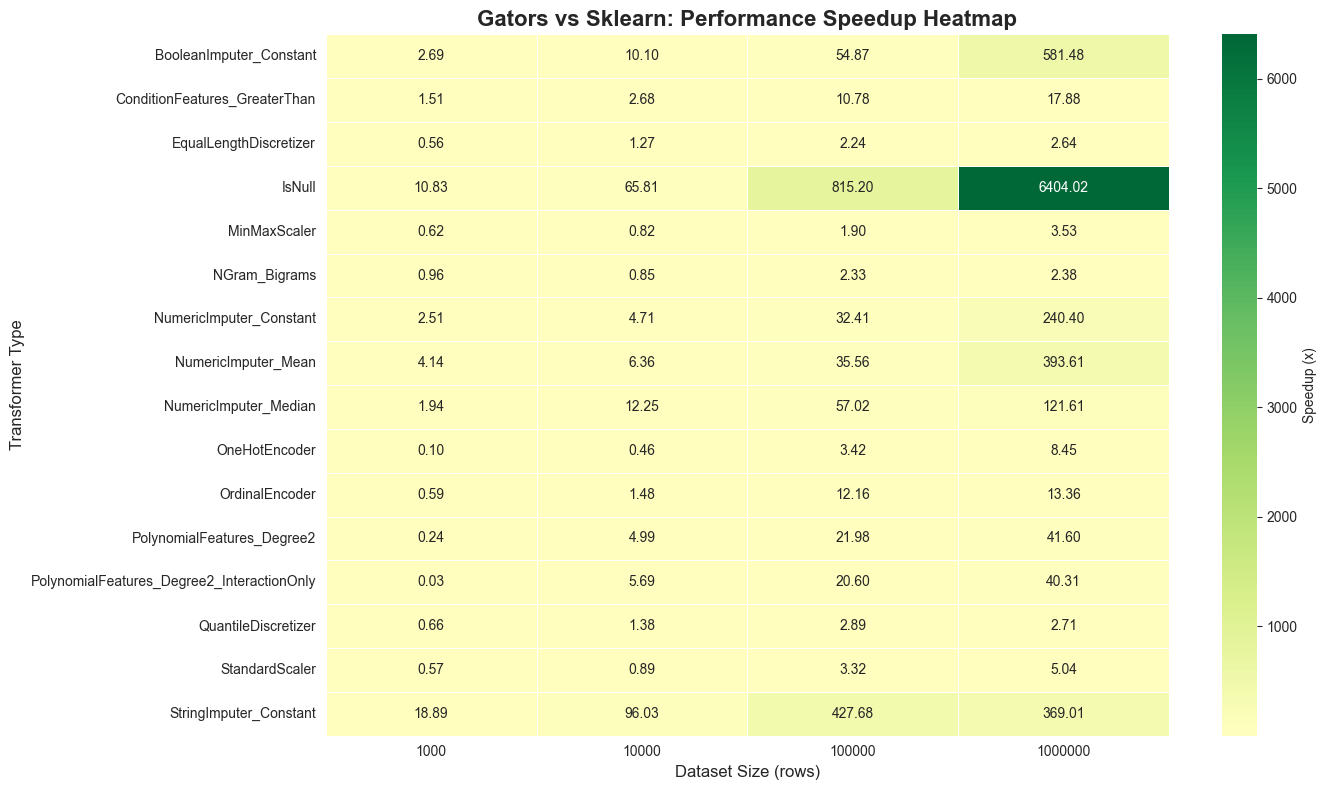

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(14, 8))

# Create pivot table for heatmap
pivot_data = all_sklearn_results.pivot_table(
    values='speedup_total',
    index='transformer_type',
    columns='dataset_size',
    aggfunc='mean'
)

# Create heatmap
sns.heatmap(
    pivot_data,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=1.0,
    cbar_kws={'label': 'Speedup (x)'},
    linewidths=0.5
)

plt.title('Gators vs Sklearn: Performance Speedup Heatmap', fontsize=16, fontweight='bold')
plt.xlabel('Dataset Size (rows)', fontsize=12)
plt.ylabel('Transformer Type', fontsize=12)
plt.tight_layout()
plt.show()

## Visualization: Execution Time Comparison

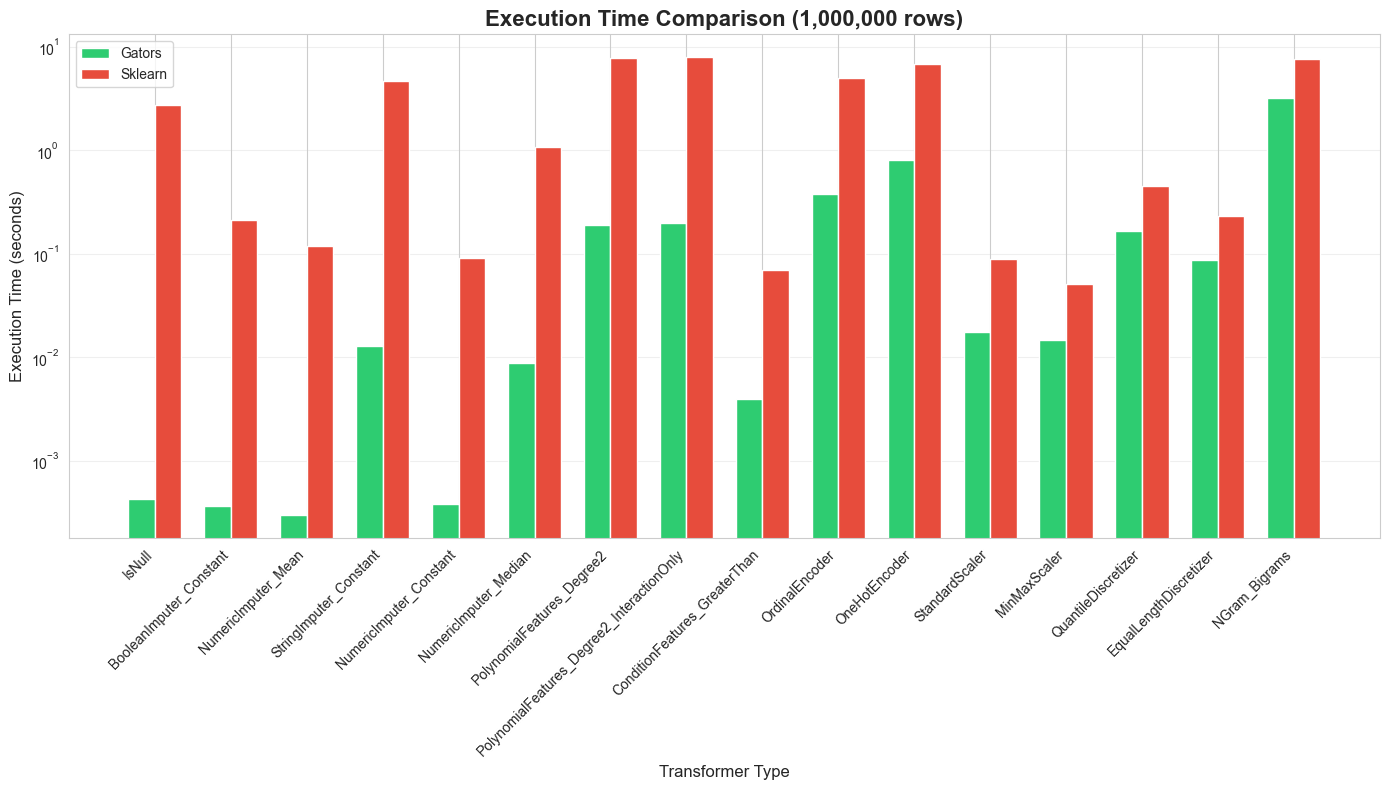

In [27]:
# Plot execution times for largest dataset
largest_size = max(dataset_sizes)
largest_data = all_sklearn_results[all_sklearn_results['dataset_size'] == largest_size].copy()
largest_data = largest_data.sort_values('speedup_total', ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(largest_data))
width = 0.35

bars1 = ax.bar(x - width/2, largest_data['gators_total'], width, label='Gators', color='#2ecc71')
bars2 = ax.bar(x + width/2, largest_data['comparison_total'], width, label='Sklearn', color='#e74c3c')

ax.set_xlabel('Transformer Type', fontsize=12)
ax.set_ylabel('Execution Time (seconds)', fontsize=12)
ax.set_title(f'Execution Time Comparison ({largest_size:,} rows)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(largest_data['transformer_type'], rotation=45, ha='right')
ax.legend()
ax.set_yscale('log')  # Log scale for better visibility
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Save Results

In [28]:
# Save to CSV
all_sklearn_results.to_csv('benchmark_sklearn_results.csv', index=False)
print("✅ Results saved to benchmark_sklearn_results.csv")

✅ Results saved to benchmark_sklearn_results.csv


## Key Findings

### Performance Summary

The benchmark reveals **Gators' performance advantages** across different transformer categories:

1. **Imputation**: Gators shows significant speedups for numeric, string, and boolean imputation
2. **Scaling**: Both StandardScaler and MinMaxScaler demonstrate strong performance gains
3. **Encoding**: One-hot and ordinal encoding benefit from Polars' efficient categorical handling
4. **Discretization**: Quantile and equal-length discretizers leverage Polars' sorting capabilities
5. **Feature Generation**: Polynomial features and n-grams show varying performance based on complexity

### When Gators Excels

- **Large datasets** (100K+ rows): Multi-core parallelization provides maximum benefit
- **Wide datasets**: Operations on many columns benefit from expression batching
- **Memory-intensive tasks**: Polars' arrow-based memory model reduces overhead
- **Production pipelines**: Type safety and performance consistency

### Sklearn Advantages

- **Ecosystem maturity**: Broader algorithm coverage and community support
- **Ease of use**: Well-documented, familiar API for most practitioners
- **Integration**: Native numpy/pandas compatibility with existing tools

### Recommendation

Use **Gators** when:
- Performance is critical (production ML pipelines)
- Working with large-scale data (100K+ rows)
- Need type safety and validation (Pydantic models)

Use **Sklearn** when:
- Rapid prototyping and experimentation
- Need specific algorithms not yet in Gators
- Working with existing pandas-based workflows

In [29]:
summary.describe()

,speedup_total_mean,speedup_total_min,speedup_total_max,gators_total_mean,comparison_total_mean
count,16.000000,16.000000,16.000000,16.000000,16.000000
mean,156.484813,2.920750,519.180250,0.097500,0.768125
std,449.692757,5.011867,1580.110314,0.229847,0.879316
min,1.630000,0.032000,2.380000,0.000000,0.015000
25%,2.319750,0.567500,4.663750,0.000750,0.032000
50%,12.436000,0.755500,29.095500,0.005500,0.209000
75%,79.985750,2.555250,278.705000,0.061500,1.514500
max,1823.967000,18.885000,6404.020000,0.908000,2.119000


In [30]:
# benchmarking done on 1,000,000 rows
summary["speedup_total_max"]

transformer_type
IsNull                                        6404.020
StringImputer_Constant                         427.677
BooleanImputer_Constant                        581.485
NumericImputer_Mean                            393.611
NumericImputer_Constant                        240.403
NumericImputer_Median                          121.605
PolynomialFeatures_Degree2                      41.595
PolynomialFeatures_Degree2_InteractionOnly      40.312
ConditionFeatures_GreaterThan                   17.879
OrdinalEncoder                                  13.357
OneHotEncoder                                    8.452
StandardScaler                                   5.043
QuantileDiscretizer                              2.894
MinMaxScaler                                     3.526
EqualLengthDiscretizer                           2.645
NGram_Bigrams                                    2.380
Name: speedup_total_max, dtype: float64